# Sprint 2 — Pipelines, muestra estratificada y balanceo

    El target está desbalanceado (~12.3% clase 1). Como el FN (falso negativo) es más costoso para el negocio, no aplicamos SMOTE por defecto, ya que podría aumentar falsos positivos y reducir precisión. Se deja como variante opcional para comparación.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import *
from src.io_utils import load_kick_data, save_df
from src.preprocessing import prepare_features, split_X_y

pd.set_option('display.max_columns', 120)
print('Proyecto:', PROJECT_ROOT)

from sklearn.model_selection import train_test_split
from src.preprocessing import build_preprocessor, get_column_groups
import joblib

Proyecto: c:\Users\PONCE\dp261-g1


In [2]:
train_full = pd.read_csv(PROCESSED_DIR / 'train_full.csv')
X_train_full, y_train_full = split_X_y(train_full)

if len(train_full) > SAMPLE_SIZE:
    X_sample, _, y_sample, _ = train_test_split(
        X_train_full, y_train_full,
        train_size=SAMPLE_SIZE,
        stratify=y_train_full,
        random_state=RANDOM_STATE
    )
else:
    X_sample, y_sample = X_train_full, y_train_full

train_sample = X_sample.copy(); train_sample[TARGET] = y_sample.values
save_df(train_sample, PROCESSED_DIR / 'train_sample.csv')
print('train_sample:', train_sample.shape)
print(y_sample.value_counts(normalize=True))

train_sample: (20000, 39)
IsBadBuy
0    0.877
1    0.123
Name: proportion, dtype: float64


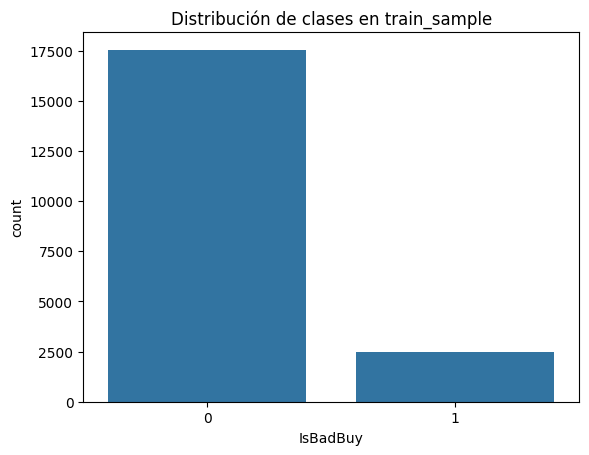

In [7]:
sns.countplot(x=y_sample)

plt.title('Distribución de clases en train_sample')

plt.show()

La muestra estratificada conserva la distribución original del target, manteniendo aproximadamente 12.3% de casos positivos (IsBadBuy = 1).

Esto permite entrenar modelos bajo condiciones similares al escenario real del negocio.

In [3]:
cols_to_drop = ['PRIMEUNIT', 'AUCGUART']

X_sample = X_sample.drop(columns=cols_to_drop, errors='ignore')
X_train_full = X_train_full.drop(columns=cols_to_drop, errors='ignore')

Luego del proceso de limpieza, el dataset quedó compuesto por:

26 variables numéricas
12 variables categóricas

Las variables categóricas corresponden principalmente a características descriptivas de los vehículos, marcas, ubicación y configuración mecánica.

In [4]:
numeric_cols, categorical_cols = get_column_groups(X_sample)
print('Numéricas:', len(numeric_cols))
print('Categóricas:', len(categorical_cols))
print('Categóricas:', categorical_cols)

Numéricas: 26
Categóricas: 12
Categóricas: ['Auction', 'Make', 'Model', 'Trim', 'SubModel', 'Color', 'Transmission', 'WheelType', 'Nationality', 'Size', 'TopThreeAmericanName', 'VNST']


In [6]:
print("Variables numéricas:")
display(numeric_cols)

print("Variables categóricas:")
display(categorical_cols)

Variables numéricas:


['VehYear',
 'VehicleAge',
 'VehOdo',
 'MMRAcquisitionAuctionAveragePrice',
 'MMRAcquisitionAuctionCleanPrice',
 'MMRAcquisitionRetailAveragePrice',
 'MMRAcquisitonRetailCleanPrice',
 'MMRCurrentAuctionAveragePrice',
 'MMRCurrentAuctionCleanPrice',
 'MMRCurrentRetailAveragePrice',
 'MMRCurrentRetailCleanPrice',
 'BYRNO',
 'VNZIP1',
 'VehBCost',
 'IsOnlineSale',
 'WarrantyCost',
 'PurchYear',
 'PurchMonth',
 'PurchQuarter',
 'PurchDayOfWeek',
 'cost_to_acq_auction_avg',
 'acq_auction_margin',
 'cost_to_current_auction_avg',
 'current_auction_margin',
 'warranty_to_cost',
 'current_vs_acq_auction_avg']

Variables categóricas:


['Auction',
 'Make',
 'Model',
 'Trim',
 'SubModel',
 'Color',
 'Transmission',
 'WheelType',
 'Nationality',
 'Size',
 'TopThreeAmericanName',
 'VNST']

Las variables categóricas representan principalmente características descriptivas de vehículos y contexto de subasta.

Estas variables requerirán estrategias específicas de codificación dependiendo del tipo de modelo utilizado.

In [5]:
preprocessors = {
    'linear': build_preprocessor(X_sample, mode='linear'),
    'tree_ohe': build_preprocessor(X_sample, mode='tree_ohe'),
    'ordinal': build_preprocessor(X_sample, mode='ordinal'),
}
MODELS_DIR.mkdir(exist_ok=True)
for name, preproc in preprocessors.items():
    joblib.dump(preproc, MODELS_DIR / f'preprocessor_{name}.pkl')
print('Preprocesadores guardados en models/')

Preprocesadores guardados en models/


No todos los modelos utilizarán exactamente el mismo conjunto de variables.

Los modelos lineales y sensibles a multicolinealidad (LogisticRegression, LinearSVM, KNN) serán entrenados principalmente utilizando variables originales limpias.

Los modelos basados en árboles (RandomForest, GradientBoosting, HistGradientBoosting) podrán aprovechar adicionalmente variables derivadas obtenidas mediante feature engineering.

Por ello, se construyen distintos pipelines de preprocesamiento adaptados al tipo de modelo.

linear: utiliza imputación, escalamiento y One-Hot Encoding, adecuado para modelos lineales.
tree_ohe: utiliza One-Hot Encoding orientado a modelos basados en árboles.
ordinal: utiliza codificación ordinal para representar categorías mediante enteros, útil para ciertos algoritmos de boosting y árboles.

In [8]:
from sklearn import set_config

set_config(display='diagram')

preprocessors['linear']

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

En esta etapa se prepararon pipelines reproducibles de preprocessing, preservando separación entre entrenamiento y test para evitar data leakage.

Además, se definió una estrategia diferenciada de variables y transformaciones según el tipo de modelo, permitiendo adaptar el preprocessing a las características particulares de cada algoritmo.

En el siguiente sprint se entrenarán modelos baseline utilizando estos pipelines y se evaluará el impacto de las variables derivadas sobre distintos tipos de modelos.